In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')

import os
import tensorflow as tf
import keras
import cv2
import glob
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from tensorflow.keras import layers , models, optimizers

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import backend as K

# **Data Generator**

In [2]:
# specifing new image shape for resnet
img_shape = 224
batch_size = 64
train_data_path = './train/'
test_data_path = './test/'

In [3]:
train_preprocessor = ImageDataGenerator(
        rescale = 1 / 255.,
        rotation_range=10,
        zoom_range=0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,                                        
        fill_mode='nearest',
        validation_split=0.25) # set validation split
    


test_preprocessor = ImageDataGenerator(
    rescale = 1 / 255.,
)

train_data = train_preprocessor.flow_from_directory(
    train_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode='rgb',
    batch_size=batch_size,
    subset='training', 
)


val_data = train_preprocessor.flow_from_directory(
    train_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode='rgb',
    batch_size=batch_size,
    subset='validation',
) # set as validation data


test_data = test_preprocessor.flow_from_directory(
    test_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=False,
    batch_size=batch_size,
)

Found 21534 images belonging to 7 classes.
Found 7175 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# **Fine-Tuning ResNet50V2**

In [4]:
ResNet50V2 = tf.keras.applications.ResNet50V2(input_shape=(224, 224, 3),
                                               include_top= False,
                                               weights='imagenet'
                                               )


In [5]:
# Freezing all layers except last 50

ResNet50V2.trainable = True

for layer in ResNet50V2.layers[:-50]:
    layer.trainable = False

In [6]:
def Create_ResNet50V2_Model():

    model = Sequential([
                      ResNet50V2,
                      Dropout(0.25),
                      BatchNormalization(),
                      Flatten(),
                      Dense(64, activation='relu'),
                      BatchNormalization(),
                      Dropout(0.5),
                      Dense(7,activation='softmax')
                    ])
    return model

In [7]:
# Macro f1-score
def f1_score(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.cast(y_true*y_pred, 'float'), axis=0)
    # tn = K.sum(K.cast((1-y_true)*(1-y_pred), 'float'), axis=0)
    fp = K.sum(K.cast((1-y_true)*y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true*(1-y_pred), 'float'), axis=0)

    p = tp / (tp + fp + K.epsilon())
    r = tp / (tp + fn + K.epsilon())

    f1 = 2*p*r / (p+r+K.epsilon())
    f1 = tf.where(tf.math.is_nan(f1), tf.zeros_like(f1), f1)
    return K.mean(f1)

In [8]:
ResNet50V2_Model = Create_ResNet50V2_Model()

ResNet50V2_Model.summary()

ResNet50V2_Model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', f1_score])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50v2 (Functional)     (None, 7, 7, 2048)        23564800  
                                                                 
 dropout (Dropout)           (None, 7, 7, 2048)        0         
                                                                 
 batch_normalization (Batch  (None, 7, 7, 2048)        8192      
 Normalization)                                                  
                                                                 
 flatten (Flatten)           (None, 100352)            0         
                                                                 
 dense (Dense)               (None, 64)                6422592   
                                                                 
 batch_normalization_1 (Bat  (None, 64)                256       
 chNormalization)                                       

**Specifying Callbacks**

In [9]:
# Create Callback Checkpoint
checkpoint_path = "ResNet50V2_Model_Checkpoint_f1.h5"

Checkpoint = ModelCheckpoint(checkpoint_path, 
                             monitor="val_f1_score", 
                             mode="max", 
                             save_best_only=True)

# Create Early Stopping Callback to monitor the accuracy
Early_Stopping = EarlyStopping(monitor = 'val_f1_score', patience = 7, restore_best_weights = True, verbose=1)

# Create ReduceLROnPlateau Callback to reduce overfitting by decreasing learning
Reducing_LR = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,
                                                  patience=2,
#                                                   min_lr=0.00005,
                                                  verbose=1)

callbacks = [Checkpoint, Early_Stopping, Reducing_LR]

steps_per_epoch = train_data.n // train_data.batch_size
validation_steps = val_data.n // val_data.batch_size

In [10]:
history = ResNet50V2_Model.fit(train_data,
                               validation_data = val_data , 
                               epochs=30, 
                               batch_size=batch_size,
                               callbacks = callbacks, 
                               steps_per_epoch=steps_per_epoch, 
                               validation_steps=validation_steps
                              )

Epoch 1/30
336/336 [==============================] - ETA: 0s - loss: 1.7259 - accuracy: 0.4293 - f1_score: 0.2097

/opt/homebrew/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


336/336 [==============================] - 741s 2s/step - loss: 1.7259 - accuracy: 0.4293 - f1_score: 0.2097 - val_loss: 1.3956 - val_accuracy: 0.5133 - val_f1_score: 0.2603 - lr: 0.0010
Epoch 2/30
336/336 [==============================] - 736s 2s/step - loss: 1.3418 - accuracy: 0.5197 - f1_score: 0.2879 - val_loss: 1.3105 - val_accuracy: 0.5402 - val_f1_score: 0.1899 - lr: 0.0010
Epoch 3/30
336/336 [==============================] - 733s 2s/step - loss: 1.2217 - accuracy: 0.5582 - f1_score: 0.3468 - val_loss: 1.3248 - val_accuracy: 0.5343 - val_f1_score: 0.2492 - lr: 0.0010
Epoch 4/30
336/336 [==============================] - 738s 2s/step - loss: 1.1574 - accuracy: 0.5838 - f1_score: 0.3838 - val_loss: 1.1360 - val_accuracy: 0.5759 - val_f1_score: 0.3706 - lr: 0.0010
Epoch 5/30
336/336 [==============================] - 746s 2s/step - loss: 1.0980 - accuracy: 0.6068 - f1_score: 0.4179 - val_loss: 1.1271 - val_accuracy: 0.6003 - val_f1_score: 0.4001 - lr: 0.0010
Epoch 6/30
336/336 [=

In [ ]:
history = ResNet50V2_Model.fit(train_data,
                               validation_data = val_data , 
                               epochs=10, 
                               batch_size=batch_size,
                               callbacks = callbacks, 
                               steps_per_epoch=steps_per_epoch, 
                               validation_steps=validation_steps
                              )

In [ ]:
#ResNet50V2_Model = models.load_model("ResNet50V2_Model_Checkpoint_f1.h5")

# **Evaluating ResNet50V2**

In [11]:
ResNet50V2_Score = ResNet50V2_Model.evaluate(test_data)

print("    Test Loss: {:.5f}".format(ResNet50V2_Score[0]))
print("Test Accuracy: {:.2f}%".format(ResNet50V2_Score[1] * 100))
print("Test F1 Score: {:.2f}%".format(ResNet50V2_Score[2] * 100))

113/113 [==============================] - 109s 962ms/step - loss: 1.2545 - accuracy: 0.5582 - f1_score: 0.0441
    Test Loss: 1.25454
Test Accuracy: 55.82%
Test F1 Score: 4.41%


In [12]:
def plot_curves(history):

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(history.history["loss"]))

    plt.figure(figsize=(15,5))

    #plot loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, loss, label = "training_loss")
    plt.plot(epochs, val_loss, label = "val_loss")
    plt.title("Loss")
    plt.xlabel("epochs")
    plt.legend()

    #plot accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, accuracy, label = "training_accuracy")
    plt.plot(epochs, val_accuracy, label = "val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("epochs")
    plt.legend()

    #plot accuracy
    plt.subplot(1, 3, 3)
    plt.plot(epochs, accuracy, label = "training_f1_score")
    plt.plot(epochs, val_accuracy, label = "val_f1_score")
    plt.title("F1 score")
    plt.xlabel("epochs")
    plt.legend()

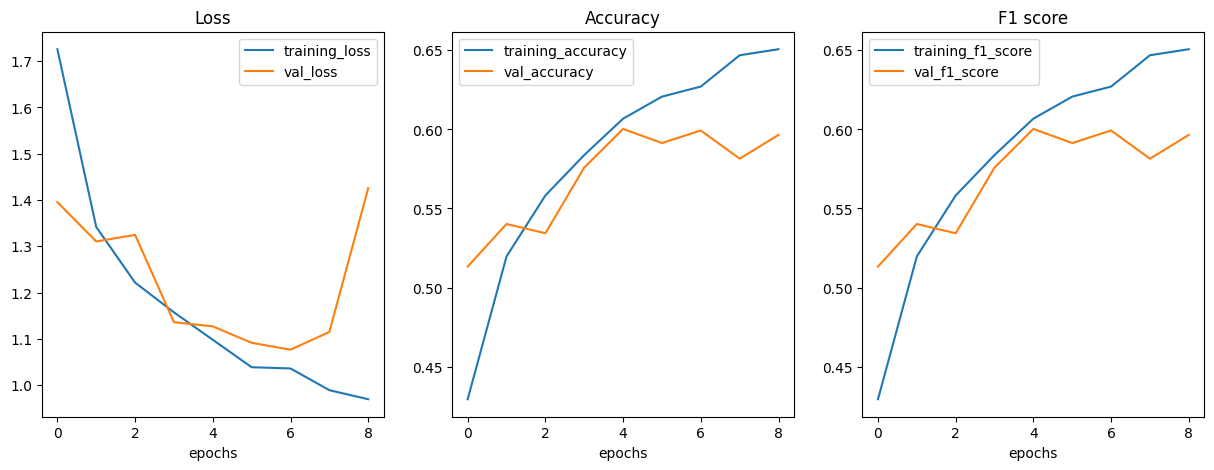

In [13]:
plot_curves(history)